Laboratório · Estimação cega de ruído gaussiano
**Processamento Digital de Imagens**

Notebook pareado com o roteiro impresso. Cada parte aqui corresponde a uma seção do PDF; execute as células na ordem e anote os resultados no relatório.

---

### Pergunta condutora

> *Como medir o ruído de uma imagem sem nunca ter visto a imagem limpa?*

### Roteiro do notebook

- **Parte A** — preparação do ambiente (imports e carregamento da imagem)
- **Parte B** — a armadilha: por que `np.std(g)` não estima ruído
- **Parte C** — duas técnicas que funcionam: diferenças e MAD
- **Parte D** — teste de estresse com 3 níveis de ruído
- **Parte D.1** — investigação opcional: o efeito do `clip`
- **Parte E** — fechamento

> **Como usar:** os parâmetros ajustáveis estão sempre destacados no topo das células de código. Mude e re-execute para experimentar.

## Parte A · Preparação

Vamos usar bibliotecas que já vêm pré-instaladas no Colab: `numpy`, `matplotlib`, `PIL` (Pillow) e `pandas` (opcional, para tabelas).

### Carregando a imagem

**No Google Colab:** vá na pasta de imagens e leia o arquivo `Fig0507_a__ckt-board-orig_.tif` quando solicitado.

Clique no botão abaixo para escolher a imagem 'Fig0507_a__ckt-board-orig_.tif' do seu Desktop:


Saving Fig0507(a)(ckt-board-orig).tif to Fig0507(a)(ckt-board-orig) (1).tif

Imagem carregada: (448, 464), dtype=float64
μ_f = 0.5912   σ_f = 0.2631
Min/Max: 0.000 / 1.000


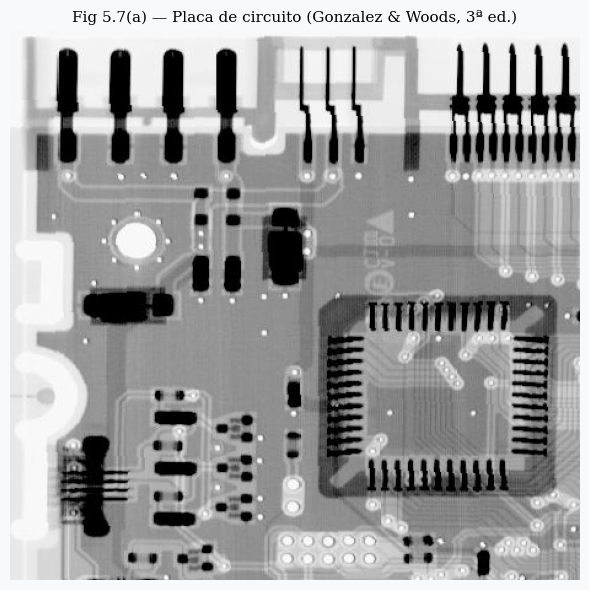

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Semente fixa para reprodutibilidade
RNG = np.random.default_rng(42)

# Estilo dos gráficos
plt.rcParams.update({
    'figure.facecolor': '#f8f9fb',
    'axes.facecolor':   '#f8f9fb',
    'font.family':      'serif',
    'axes.spines.top':  False,
    'axes.spines.right': False,
})

print("Clique no botão abaixo para escolher a imagem 'Fig0507_a__ckt-board-orig_.tif' do seu Desktop:")

# Abre a "janelinha" (botão de upload) no Colab
uploaded = files.upload()

# Pega o nome do arquivo que o usuário selecionou
ARQUIVO = list(uploaded.keys())[0]

# Carregar a imagem, normalizada para [0, 1]
f = np.array(Image.open(ARQUIVO), dtype=float) / 255.0

print(f'\nImagem carregada: {f.shape}, dtype={f.dtype}')
print(f'μ_f = {f.mean():.4f}   σ_f = {f.std():.4f}')
print(f'Min/Max: {f.min():.3f} / {f.max():.3f}')

# Visualizar
fig, ax = plt.subplots(figsize=(7, 6))
ax.imshow(f, cmap='gray', vmin=0, vmax=1)
ax.set_title('Fig 5.7(a) — Placa de circuito (Gonzalez & Woods, 3ª ed.)', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.show()

### Observe a imagem

Note duas coisas que vão ser importantes adiante:

1. **Regiões lisas** — o substrato cinza da placa, áreas entre componentes.
2. **Bordas fortíssimas** — os pinos do conector no topo, as trilhas, e principalmente o **fundo preto** que circunda a placa (cerca de 6% dos pixels valem exatamente zero).

Essa combinação é o que torna a imagem um excelente teste para os estimadores que vamos construir.

## Parte B · A primeira tentativa (e o tombo)

### Atividade B.1 — Estimador ingênuo

Sua primeira tentativa: o desvio-padrão da imagem inteira é uma boa estimativa de σ?

Vamos adicionar ruído com **σ = 0.08** (equivalente à variância 400 do exemplo 5.2 do Gonzalez em 8-bit) e medir.

sigma verdadeiro:      0.0800
sigma estimado (std):  0.2644
erro absoluto:         0.1844


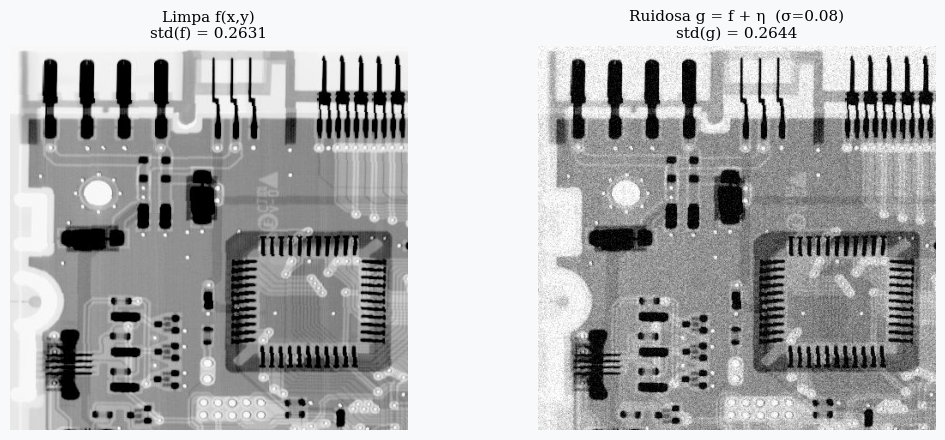

In [2]:
# ═══════════════════ PARÂMETROS ═════════════════════════════
sigma_verdadeiro = 0.08    # equivalente a var=400 em 8-bit
# ════════════════════════════════════════════════════════════

# Gerar ruído gaussiano e somar à imagem
ruido = RNG.normal(0, sigma_verdadeiro, f.shape)
g = np.clip(f + ruido, 0, 1)

# Estimador ingênuo: desvio-padrão da imagem inteira
sigma_global = g.std()

print(f'sigma verdadeiro:      {sigma_verdadeiro:.4f}')
print(f'sigma estimado (std):  {sigma_global:.4f}')
print(f'erro absoluto:         {abs(sigma_global - sigma_verdadeiro):.4f}')

# Visualização lado a lado
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(f, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Limpa f(x,y)\nstd(f) = {f.std():.4f}', fontsize=11)
axes[1].imshow(g, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Ruidosa g = f + η  (σ={sigma_verdadeiro})\nstd(g) = {g.std():.4f}',
                  fontsize=11)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Pergunta:** o valor estimado bate com o verdadeiro? Por quanto erra?

### Atividade B.2 — A revelação do problema

Agora faça o mesmo cálculo, mas **na imagem limpa** (sem adicionar ruído nenhum):

In [3]:
print(f'std da imagem LIMPA (sem ruído): {f.std():.4f}')
print(f'σ de ruído nominal:              0.0000')
print()
print('Se np.std fosse um bom estimador de σ, deveria dar')
print(f'quase zero numa imagem sem ruído. Não dá: dá {f.std():.4f}.')
print('Por quê?')

std da imagem LIMPA (sem ruído): 0.2631
σ de ruído nominal:              0.0000

Se np.std fosse um bom estimador de σ, deveria dar
quase zero numa imagem sem ruído. Não dá: dá 0.2631.
Por quê?


### Explicação: variância espacial vs. variância do ruído

Quando você calcula `np.std(g)`, está medindo a variabilidade dos valores dos pixels **no espaço da imagem** — o quanto eles diferem entre si. Essa variação tem duas fontes:

1. **Estrutura do sinal:** as trilhas são escuras, o substrato é claro, há o fundo preto fora da placa. Os pixels variam bastante entre si — eles *deveriam* variar, é o que torna a imagem reconhecível.
2. **Ruído aleatório:** a flutuação que se sobrepõe à imagem.

Como sinal e ruído são independentes, a variância da soma é a soma das variâncias:

$$ \mathrm{Var}_{\text{espacial}}(g) \;=\; \mathrm{Var}_{\text{espacial}}(f) \;+\; \mathrm{Var}(\eta) $$

Para a placa de circuito, $\sigma_f \approx 0{,}26$ e $\sigma_\eta = 0{,}08$. Substituindo:

$$ \sigma_g \;=\; \sqrt{0{,}26^2 + 0{,}08^2} \;\approx\; 0{,}272 $$

O ruído está lá, mas perdido dentro da variabilidade do sinal. A estrutura da imagem domina a estimativa.

**Conclusão:** para medir só o ruído, precisamos de uma estatística que **ignore a estrutura** da imagem e olhe apenas para a flutuação aleatória.

Vamos verificar a relação na prática:

In [4]:
sigma_g_previsto = np.sqrt(f.std()**2 + sigma_verdadeiro**2)
sigma_g_medido   = g.std()

print(f'σ_f (variabilidade do sinal):       {f.std():.4f}')
print(f'σ_η (ruído verdadeiro):             {sigma_verdadeiro:.4f}')
print(f'σ_g previsto = √(σ_f² + σ_η²):      {sigma_g_previsto:.4f}')
print(f'σ_g medido em g:                    {sigma_g_medido:.4f}')
print()
print('Note: o σ_g medido bate quase exatamente com o previsto pela soma de')
print('variâncias. Confirma que std(g) está medindo SINAL+RUÍDO, não só ruído.')

σ_f (variabilidade do sinal):       0.2631
σ_η (ruído verdadeiro):             0.0800
σ_g previsto = √(σ_f² + σ_η²):      0.2749
σ_g medido em g:                    0.2644

Note: o σ_g medido bate quase exatamente com o previsto pela soma de
variâncias. Confirma que std(g) está medindo SINAL+RUÍDO, não só ruído.


## Parte C · Duas técnicas que funcionam

### C.1 — Diferenças entre pixels vizinhos

A ideia central: em regiões **suaves** da imagem (por exemplo, no substrato da placa, longe das trilhas), pixels vizinhos têm valores parecidos. Se subtrairmos um do outro:

$$ d[i] \;=\; g[i+1] - g[i] $$

Expandindo $g = f + \eta$:

$$ d[i] \;=\; \underbrace{(f[i+1] - f[i])}_{\approx\, 0 \text{ em região suave}} \;+\; \underbrace{(\eta[i+1] - \eta[i])}_{\text{só ruído}} $$

O sinal se cancela, e sobra a diferença de dois ruídos. Cada ruído é gaussiano com variância $\sigma^2$; a diferença de dois gaussianos independentes é também gaussiana, mas com variância $2\sigma^2$ (variâncias se somam mesmo na subtração). Logo:

$$ \mathrm{std}(d) \;=\; \sqrt{2}\,\sigma \qquad\Longrightarrow\qquad \boxed{\;\hat{\sigma}_{\text{diff}} \;=\; \frac{\mathrm{std}(d)}{\sqrt{2}}\;} $$

A divisão por $\sqrt{2}$ **não é arbitrária** — ela compensa o fato de que estamos medindo a diferença entre dois ruídos em vez de um só.

### Atividade C.1 — Implementação e teste

In [5]:
def estimar_sigma_diff(img):
    """Estimador por diferenças horizontais."""
    d = np.diff(img, axis=1)        # diferenças entre vizinhos
    return d.std() / np.sqrt(2)     # corrige pelo fator √2

# Testar com a imagem ruidosa da Atividade B.1
print(f'sigma verdadeiro:              {sigma_verdadeiro:.4f}')
print(f'sigma estimado (global B.1):   {g.std():.4f}')
print(f'sigma estimado (diff C.1):     {estimar_sigma_diff(g):.4f}')
print()
print('Compare os três valores.')

sigma verdadeiro:              0.0800
sigma estimado (global B.1):   0.2644
sigma estimado (diff C.1):     0.0972

Compare os três valores.


**Pergunta:** agora o erro é grande ou pequeno? Compare com o resultado da Parte B.

### Atividade C.2 — Onde o método das diferenças falha

A hipótese "vizinhos têm valores parecidos" vale na maior parte da imagem, mas **quebra em bordas reais**. Olhe para a região superior da placa, onde estão os pinos do conector — as transições do escuro do pino para o claro do substrato são abruptas. Nessas transições, $f[i+1] - f[i]$ pode valer 0.5 ou mais. Isso vira um valor enorme na lista de diferenças e infla o desvio-padrão.

Vamos verificar.

sigma verdadeiro:           0.0800
diff (imagem inteira):      0.0972
diff (recorte pinos):       0.1171

Erro absoluto (inteira):    0.0172
Erro absoluto (pinos):      0.0371


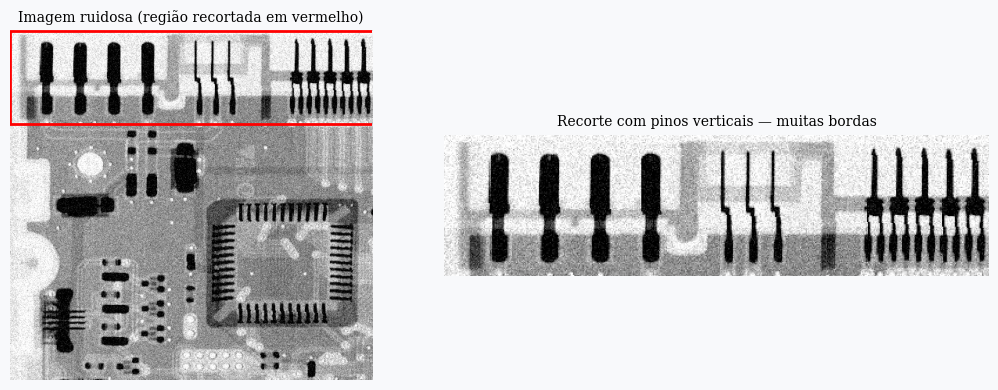

In [6]:
# Recorte com bordas fortes: parte superior com os pinos
recorte_pinos = g[0:120, :]

print(f'sigma verdadeiro:           {sigma_verdadeiro:.4f}')
print(f'diff (imagem inteira):      {estimar_sigma_diff(g):.4f}')
print(f'diff (recorte pinos):       {estimar_sigma_diff(recorte_pinos):.4f}')
print()
print(f'Erro absoluto (inteira):    {abs(estimar_sigma_diff(g) - sigma_verdadeiro):.4f}')
print(f'Erro absoluto (pinos):      {abs(estimar_sigma_diff(recorte_pinos) - sigma_verdadeiro):.4f}')

# Visualizar o recorte para o aluno entender
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(g, cmap='gray', vmin=0, vmax=1)
axes[0].add_patch(plt.Rectangle((0, 0), g.shape[1], 120,
                                fill=False, edgecolor='red', linewidth=2))
axes[0].set_title('Imagem ruidosa (região recortada em vermelho)', fontsize=10)
axes[1].imshow(recorte_pinos, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Recorte com pinos verticais — muitas bordas', fontsize=10)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observação:** o estimador superestima em regiões com bordas. Quanto mais bordas, mais ele erra para cima.

Vamos ver isso graficamente — onde estão as "diferenças extremas" que estão estragando o estimador?

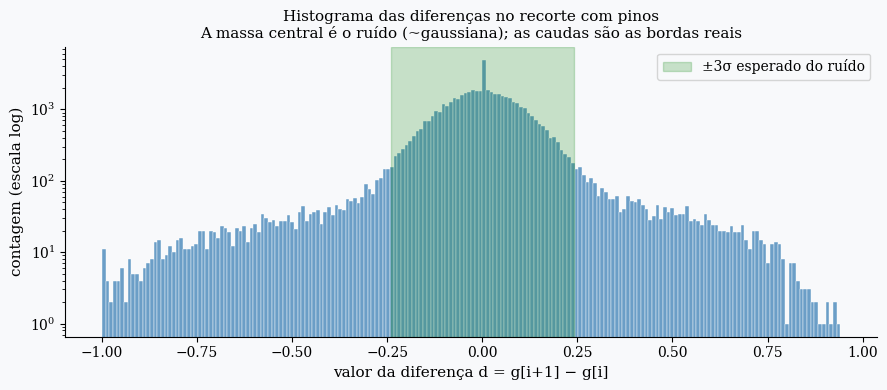

Note as caudas: valores de d acima de ±0.3 NÃO são ruído gaussiano,
são as bordas reais dos pinos. Mas o std() conta tudo igualmente!


In [7]:
# Histograma das diferenças no recorte com bordas
d_recorte = np.diff(recorte_pinos, axis=1).ravel()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(d_recorte, bins=200, color='#6b9ec7', edgecolor='white', linewidth=0.3)
ax.set_yscale('log')   # log para ver as caudas
ax.set_xlabel('valor da diferença d = g[i+1] − g[i]', fontsize=11)
ax.set_ylabel('contagem (escala log)', fontsize=11)
ax.set_title('Histograma das diferenças no recorte com pinos\n'
             'A massa central é o ruído (~gaussiana); as caudas são as bordas reais',
             fontsize=11)
ax.axvspan(-3*sigma_verdadeiro, 3*sigma_verdadeiro, alpha=0.2, color='green',
           label='±3σ esperado do ruído')
ax.legend()
plt.tight_layout()
plt.show()

print('Note as caudas: valores de d acima de ±0.3 NÃO são ruído gaussiano,')
print('são as bordas reais dos pinos. Mas o std() conta tudo igualmente!')

### C.2 — MAD: ignorando as bordas com elegância

Para consertar isso, trocamos o desvio-padrão por uma estatística que **não é afetada por valores extremos**: o MAD (*median absolute deviation*).

**Como o MAD funciona:** dado um vetor, calcula-se primeiro a mediana, depois a mediana dos módulos dos desvios em relação a ela:

$$ \mathrm{MAD}(d) \;=\; \mathrm{mediana}\big(\, |\, d - \mathrm{mediana}(d)\,|\, \big) $$

A mediana é **imune a outliers**: se 5% dos valores de $d$ são gigantescos (correspondendo a bordas reais), a mediana simplesmente os ignora — eles vão parar nas pontas da lista ordenada, e ela só olha o meio.

Para uma distribuição gaussiana pura, MAD e $\sigma$ se relacionam por $\mathrm{MAD} = 0{,}6745\,\sigma$. Combinando com o fator $\sqrt{2}$ da diferença:

$$ \boxed{\;\hat{\sigma}_{\text{MAD}} \;=\; \frac{\mathrm{MAD}(d)}{0{,}6745 \cdot \sqrt{2}} \;\approx\; \frac{\mathrm{MAD}(d)}{0{,}9539}\;} $$

Os números $0{,}6745$ e $0{,}9539$ parecem mágicos mas têm origem clara: $0{,}6745$ é a razão entre MAD e $\sigma$ para a distribuição normal padrão (tabelado em qualquer livro de estatística), e $\sqrt{2}$ vem do mesmo raciocínio da diferença de gaussianas.

### Atividade C.3 — Implementação e comparação

In [8]:
def estimar_sigma_mad(img):
    """Estimador robusto por MAD das diferenças."""
    d = np.diff(img, axis=1).ravel()
    mad = np.median(np.abs(d - np.median(d)))
    return mad / 0.9539

print(f'sigma verdadeiro:                  {sigma_verdadeiro:.4f}')
print()
print(f'sigma (diff) imagem inteira:       {estimar_sigma_diff(g):.4f}')
print(f'sigma (MAD)  imagem inteira:       {estimar_sigma_mad(g):.4f}')
print()
print(f'sigma (diff) recorte pinos:        {estimar_sigma_diff(recorte_pinos):.4f}')
print(f'sigma (MAD)  recorte pinos:        {estimar_sigma_mad(recorte_pinos):.4f}')
print()
print('Observe: o MAD recupera o σ verdadeiro mesmo no recorte com muitos pinos.')
print('É essa robustez que o torna o método padrão na prática.')

sigma verdadeiro:                  0.0800

sigma (diff) imagem inteira:       0.0972
sigma (MAD)  imagem inteira:       0.0795

sigma (diff) recorte pinos:        0.1171
sigma (MAD)  recorte pinos:        0.0755

Observe: o MAD recupera o σ verdadeiro mesmo no recorte com muitos pinos.
É essa robustez que o torna o método padrão na prática.


## Parte D · Teste de estresse

Vamos quantificar a comparação variando o nível de ruído. Para cada σ na lista, geramos uma imagem ruidosa e aplicamos os três estimadores.

In [9]:
import pandas as pd

# ═══════════════════ PARÂMETROS ═════════════════════════════
niveis = [0.02, 0.08, 0.20]   # baixo, Gonzalez (var=400), forte
# ════════════════════════════════════════════════════════════

# Recriar RNG para reprodutibilidade
rng_d = np.random.default_rng(42)

resultados = []
for s in niveis:
    ruido = rng_d.normal(0, s, f.shape)
    g = np.clip(f + ruido, 0, 1)
    resultados.append({
        'σ verdadeiro': s,
        'global (std)':  g.std(),
        'diff':          estimar_sigma_diff(g),
        'MAD':           estimar_sigma_mad(g),
        'erro global':   abs(g.std() - s),
        'erro diff':     abs(estimar_sigma_diff(g) - s),
        'erro MAD':      abs(estimar_sigma_mad(g) - s),
    })

df = pd.DataFrame(resultados)
print(df.round(4).to_string(index=False))

 σ verdadeiro  global (std)   diff    MAD  erro global  erro diff  erro MAD
         0.02        0.2623 0.0667 0.0276       0.2423     0.0467    0.0076
         0.08        0.2646 0.0968 0.0790       0.1846     0.0168    0.0010
         0.20        0.2901 0.1857 0.1749       0.0901     0.0143    0.0251


**Observe:** o erro absoluto do estimador global é sempre da ordem de $\sigma_f \approx 0{,}26$ (variabilidade natural da placa), **independente do ruído real**. Ele *não vê o ruído*, só vê a estrutura da imagem. Já diff e MAD acompanham o ruído verdadeiro de perto.

Vamos ver isso visualmente:

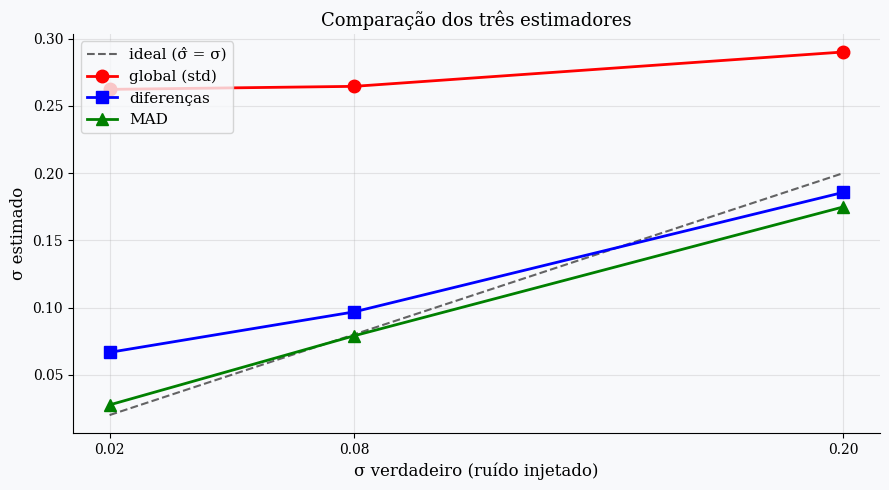

A linha tracejada preta é o estimador ideal. Quanto mais próximo dela,
melhor o estimador. Note como o vermelho (global) fica numa horizontal
em ~0.26: ele simplesmente não enxerga o ruído.


In [10]:
# Plot comparativo
fig, ax = plt.subplots(figsize=(9, 5))

x = np.array(niveis)
ax.plot(x, x, 'k--', linewidth=1.5, label='ideal (σ̂ = σ)', alpha=0.6)
ax.plot(x, df['global (std)'], 'r-o', linewidth=2, markersize=9, label='global (std)')
ax.plot(x, df['diff'],         'b-s', linewidth=2, markersize=9, label='diferenças')
ax.plot(x, df['MAD'],          'g-^', linewidth=2, markersize=9, label='MAD')

ax.set_xlabel('σ verdadeiro (ruído injetado)', fontsize=12)
ax.set_ylabel('σ estimado', fontsize=12)
ax.set_title('Comparação dos três estimadores', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xticks(niveis)
plt.tight_layout()
plt.show()

print('A linha tracejada preta é o estimador ideal. Quanto mais próximo dela,')
print('melhor o estimador. Note como o vermelho (global) fica numa horizontal')
print('em ~0.26: ele simplesmente não enxerga o ruído.')

### Atenção ao detalhe: o efeito do `clip`

Você deve ter notado uma curiosidade na linha de σ = 0.20: o MAD recupera ≈ 0.17, e não 0.20. Isso **não é falha do estimador** — é uma consequência do `np.clip(f + ruido, 0, 1)` que aplicamos para garantir que a imagem fique no intervalo válido.

A imagem da placa tem cerca de 6% de pixels já saturados em zero (o fundo preto da radiografia) e algumas regiões claras próximas de 1. Com ruído forte, parte significativa das amostras de η tenta empurrar esses pixels para fora do intervalo [0, 1] — e o clip os trava nas bordas. Resultado: o ruído **efetivamente presente** na imagem g entregue ao estimador tem desvio menor que o σ que pedimos ao gerador.

Vamos verificar isso explicitamente:

In [11]:
rng_clip = np.random.default_rng(42)

print(f"{'σ pedido':>10} {'σ antes clip':>14} {'σ após clip':>14} {'% clipados':>12}")
print('-' * 56)
for s in [0.02, 0.05, 0.08, 0.10, 0.15, 0.20, 0.30]:
    rng_local = np.random.default_rng(42)
    ruido = rng_local.normal(0, s, f.shape)
    g_pre = f + ruido          # ANTES do clip
    g_pos = np.clip(g_pre, 0, 1)   # APÓS o clip
    ruido_efetivo = g_pos - f      # ruído que realmente sobrou
    clipados = ((g_pre < 0) | (g_pre > 1)).mean() * 100
    print(f'{s:>10.3f} {ruido.std():>14.4f} {ruido_efetivo.std():>14.4f} {clipados:>11.1f}%')

print()
print('Em σ=0.20: ~15% dos pixels são clipados, e o σ EFETIVO cai para ~0.18.')
print('O MAD acerta esse σ efetivo perfeitamente — não está errando o ruído,')
print('está acertando o ruído que realmente existe na imagem após o clip.')

  σ pedido   σ antes clip    σ após clip   % clipados
--------------------------------------------------------
     0.020         0.0200         0.0195         4.6%
     0.050         0.0501         0.0479         7.2%
     0.080         0.0802         0.0756         9.2%
     0.100         0.1002         0.0939        10.3%
     0.150         0.1503         0.1384        12.7%
     0.200         0.2005         0.1802        15.4%
     0.300         0.3007         0.2518        22.6%

Em σ=0.20: ~15% dos pixels são clipados, e o σ EFETIVO cai para ~0.18.
O MAD acerta esse σ efetivo perfeitamente — não está errando o ruído,
está acertando o ruído que realmente existe na imagem após o clip.


### Atividade D.1 (opcional) — Isolando o efeito do clip

Como você modificaria a Parte D para **isolar a contribuição do clipping** na diferença entre σ pedido e σ estimado?

Uma forma natural é rodar **dois experimentos paralelos**: um com clip e outro sem para depois comparar. Vamos fazer isso:

 σ pedido  MAD (sem clip)  MAD (com clip)
     0.02          0.0288          0.0276
     0.05          0.0582          0.0541
     0.08          0.0878          0.0795
     0.15          0.1572          0.1366
     0.20          0.2067          0.1752
     0.30          0.3053          0.2423


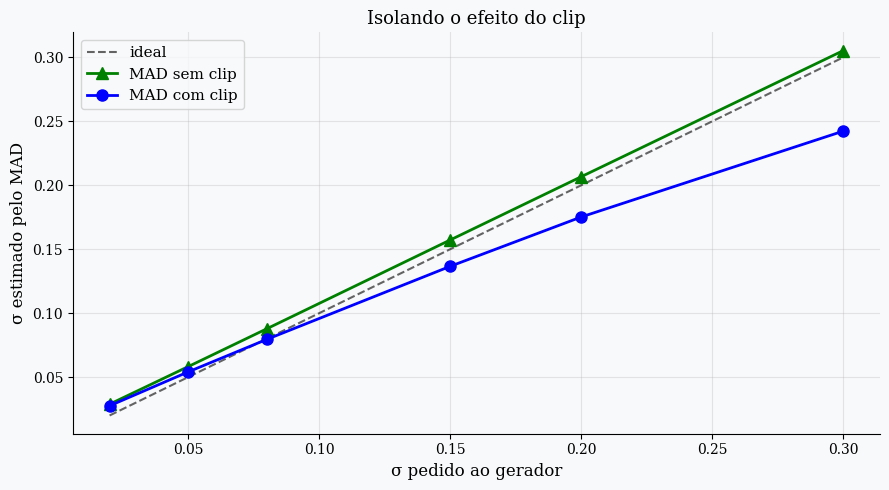


Observe:
 • MAD sem clip cola na linha ideal — recupera σ perfeitamente.
 • MAD com clip diverge gradualmente em σ alto — não por falha do MAD,
   mas porque o clip está reduzindo o ruído de fato presente.


In [12]:
rng_e = np.random.default_rng(42)

niveis_completo = [0.02, 0.05, 0.08, 0.15, 0.20, 0.30]
resultados_clip = []

for s in niveis_completo:
    rng_local = np.random.default_rng(42)
    ruido = rng_local.normal(0, s, f.shape)

    # Versão SEM clip (atenção: pode ter valores fora de [0,1] — só para análise)
    g_sem_clip = f + ruido

    # Versão COM clip (a do experimento principal)
    g_com_clip = np.clip(g_sem_clip, 0, 1)

    resultados_clip.append({
        'σ pedido':          s,
        'MAD (sem clip)':    estimar_sigma_mad(g_sem_clip),
        'MAD (com clip)':    estimar_sigma_mad(g_com_clip),
    })

df_clip = pd.DataFrame(resultados_clip)
print(df_clip.round(4).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
x = np.array(niveis_completo)
ax.plot(x, x, 'k--', linewidth=1.5, label='ideal', alpha=0.6)
ax.plot(x, df_clip['MAD (sem clip)'], 'g-^', linewidth=2, markersize=8,
        label='MAD sem clip')
ax.plot(x, df_clip['MAD (com clip)'], 'b-o', linewidth=2, markersize=8,
        label='MAD com clip')
ax.set_xlabel('σ pedido ao gerador', fontsize=12)
ax.set_ylabel('σ estimado pelo MAD', fontsize=12)
ax.set_title('Isolando o efeito do clip', fontsize=13)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nObserve:')
print(' • MAD sem clip cola na linha ideal — recupera σ perfeitamente.')
print(' • MAD com clip diverge gradualmente em σ alto — não por falha do MAD,')
print('   mas porque o clip está reduzindo o ruído de fato presente.')

**Conclusão da investigação:** o MAD é um estimador correto em ambos os casos. A diferença entre σ pedido e σ estimado em ruído forte vem do **clipping**, não da estatística.

Em sensores reais isso é exatamente o que acontece: pixels que estouram o limite de saturação travam, e o ruído "visível" na imagem é menor que o ruído "analógico" antes da saturação. **O estimador está dando a resposta certa para a pergunta certa.**

## Parte E · Voltando ao mundo real

Agora vc tem em mãos exatamente a ferramenta que o ISP de um celular precisa: um estimador automático e robusto de σ, sem nunca ter visto a imagem limpa. Em hardware dedicado, isso é implementado em **uma única passagem pela imagem** (2 linhas de C ou de Verilog) e roda a cada frame, em tempo real, antes do filtro gaussiano.

Num pipeline real O ISP precisa decidir, frame a frame, se aplica um kernel 5×5 ou 21×21 (e portanto se gasta 10 ou 42 multiplicações por pixel via separabilidade). Essa decisão depende do σ estimado:

- ruído fraco → kernel pequeno → menos borramento
- ruído forte → kernel grande → mais suavização

Sem a estimação automática, o filtro seria ou genérico demais (sempre o mesmo $k$) ou impossível de configurar.

Os estimadores que você implementou hoje (diferenças e MAD)  são, em essência, o que está rodando dentro do silício da câmera do seu celular toda vez que você tira uma foto à noite.

---

### Aplicação final: dimensionando um filtro

Vamos fechar com um exercício prático que combina tudo: dado o σ estimado, qual o tamanho de kernel para um SNR alvo?

σ estimado pelo MAD: 0.1125
σ alvo (desejado após filtro): 0.0300
Kernel mínimo: k = 5  (filtro 5×5)
Ganho de SNR esperado: ~5× (lei do √N)
σ medido após filtragem: 0.0149  (alvo: ≤ 0.0300)


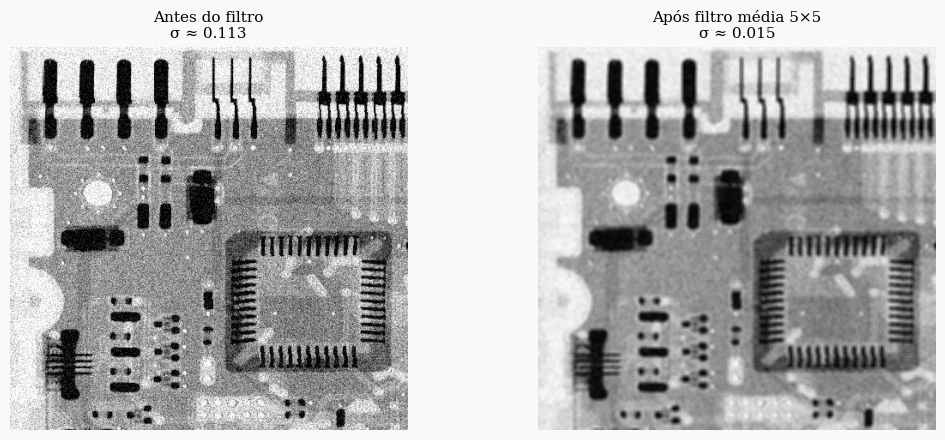

In [13]:
# Você acabou de receber uma imagem com ruído desconhecido.
# Vamos simular: ruído com σ secreto, e você estima sem saber qual é.

sigma_secreto = 0.12   # imagine que você NÃO sabe esse valor
ruido_secreto = np.random.default_rng(7).normal(0, sigma_secreto, f.shape)
g_misterio = np.clip(f + ruido_secreto, 0, 1)

# Passo 1: estimar o ruído usando o MAD
sigma_estimado = estimar_sigma_mad(g_misterio)
print(f'σ estimado pelo MAD: {sigma_estimado:.4f}')

# Passo 2: decidir o kernel para reduzir o ruído a σ_alvo
sigma_alvo = 0.03   # queremos que o ruído residual fique abaixo deste valor
k_necessario = int(np.ceil(sigma_estimado / sigma_alvo))
# Garantir que k seja ímpar (kernel centralizado)
if k_necessario % 2 == 0:
    k_necessario += 1

print(f'σ alvo (desejado após filtro): {sigma_alvo:.4f}')
print(f'Kernel mínimo: k = {k_necessario}  (filtro {k_necessario}×{k_necessario})')
print(f'Ganho de SNR esperado: ~{k_necessario}× (lei do √N)')

# Passo 3: aplicar o filtro
from scipy.ndimage import uniform_filter
g_filtrada = uniform_filter(g_misterio, size=k_necessario)
sigma_residual = estimar_sigma_mad(g_filtrada)

print(f'σ medido após filtragem: {sigma_residual:.4f}  (alvo: ≤ {sigma_alvo:.4f})')

# Visualizar antes e depois
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].imshow(g_misterio, cmap='gray', vmin=0, vmax=1)
axes[0].set_title(f'Antes do filtro\nσ ≈ {sigma_estimado:.3f}', fontsize=11)
axes[1].imshow(g_filtrada, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Após filtro média {k_necessario}×{k_necessario}\nσ ≈ {sigma_residual:.3f}',
                  fontsize=11)
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Síntese final

| O que verificamos | Resultado |
|---|---|
| `np.std(g)` estima ruído? | Mistura sinal e ruído — falha |
| Diferenças entre vizinhos cancelam sinal em regiões suaves? | Sim — recupera σ no caso geral |
| Diferenças funcionam em regiões com bordas? | Não — superestima |
| MAD das diferenças resolve o problema das bordas? | Sim — é robusto |
| O `clip` muda o σ que o estimador deveria recuperar? | Sim — em ruído forte |
| Dá para usar o σ estimado para dimensionar filtro? | Sim — pipeline completo |

---

## Para a Apresentação

Tente responder em sua apresentação e se necessário pesquise:

1. No primeiro experimento, quando tentamos medir o ruído simplesmente calculando o desvio padrão da imagem inteira (usando np.std), o valor calculado fica muito maior do que o ruído real. Na prática, o que esse cálculo está medindo junto com o ruído que faz o resultado dar tão errado?
2. Nos métodos que realmente funcionam (como o estimador de diferenças), o código não olha para o valor do pixel isolado, mas sim para a diferença entre um pixel e o seu vizinho. Por que calcular a 'diferença entre vizinhos' ajuda a ignorar o desenho da foto e enxergar só o ruído?
3. Você tem duas fotos da mesma cena: uma de dia (SNR alto) e uma de noite (SNR baixo, ruído visível). Em qual delas o MAD se sai melhor? Por quê?
4. Se você estimou σ = 0.10 e quer reduzir o ruído para 0.02, qual o menor $k$ necessário?
5. No último experimento, quando colocamos um ruído muito forte na imagem, precisamos usar a função clip para cortar os valores que passam de 1 (branco máximo) ou caem abaixo de 0 (preto máximo). O que esse 'corte' acaba fazendo com a força do ruído que sobrou na imagem? Ele parece maior ou menor do que deveria?

Ao preparar sua apresentação não se esqueça de mostrar:
- A tabela completa da Parte D
- Capturas de tela dos plots das Atividades B.1, C.2 e D.1
- Comentários sobre quaisquer descobertas inesperadas

---

*Esse Notebook deve ser usado após ler o Roteiro. Use junto com as imagens fornecidas pelo livro: uma sem ruído e outra com para comparação. Teste os parâmetros descritos no livro.*